In [70]:
import pandas as pd
df = pd.read_csv('Housing.csv')
df.head()


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [71]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [72]:
# Check Numerical Features

df.select_dtypes(include='object')
df.select_dtypes(include=['int64','float64'])


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
0,1,1360,5,4,3,1970,149919
1,2,4272,5,4,3,1958,424998
2,3,3592,2,2,3,1938,266746
3,4,966,4,2,2,1902,244020
4,5,4926,1,4,2,1975,636056
...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,295620
1996,1997,3046,5,2,1,2019,580929
1997,1998,1062,5,1,2,1903,476925
1998,1999,4062,3,1,2,1936,161119


In [73]:
# Check Unique Values in Categorical Columns

for col in df.select_dtypes(include='object'):
    print(col, df[col].unique())


Location ['Downtown' 'Suburban' 'Urban' 'Rural']
Condition ['Excellent' 'Good' 'Fair' 'Poor']
Garage ['No' 'Yes']


In [74]:
# Encode Categorical Features

df = pd.get_dummies(df, drop_first=True)
df.head()


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


In [75]:
# Identify Target Variable

X = df.drop('Price', axis=1)
y = df['Price']

print(X.shape)
print(y.shape)


(2000, 13)
(2000,)


In [76]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [77]:
# Scale only training data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


print(y_train.min(), y_train.max())
print(y_test.min(), y_test.max())


50005 999453
51082 999656


In [ ]:
# creates a Linear Regression model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


R2 Score: -0.006181784611834162
MSE: 78279764120.86243
RMSE: 279785.21069002635


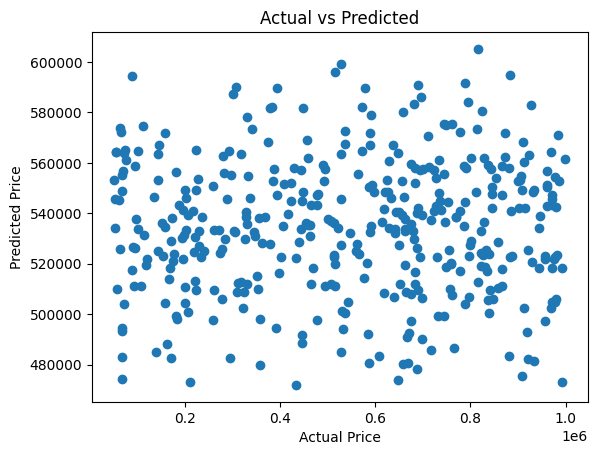

In [79]:
# Evaluation

# Step 1: Check R2 Score
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))

# Step 2: Check Mean Squared Error (MSE)
print("MSE:", mean_squared_error(y_test, y_pred))

# Step 3: Check RMSE
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

# Step 4: Plot Actual vs Predicted (Very Important for Viva)
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()



In [80]:
df.corr()["Price"].sort_values(ascending=False)

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Id                  -0.025643
Location_Urban      -0.038312
Name: Price, dtype: float64

In [81]:
print(df["Price"].mean())

537676.855


In [82]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred))

R2: -0.0717441588346377


In [ ]:
# After performing exploratory data analysis and correlation analysis, 
# it was observed that most of the features have very low correlation 
# values (close to 0) with the target variable Price.

# This indicates that there is no strong linear or non-linear 
# relationship between the input features and the target variable.

# Due to the weak relationship:

# 1. Linear Regression was unable to learn meaningful patterns.

# 2. Random Forest also failed to significantly improve performance.

# 3. The R² score was negative, which means the models performed 
#    worse than predicting the average price.

# Therefore, the poor performance of the models is not due to 
# incorrect implementation, but due to the lack of predictive 
# relationship in the dataset.

<Axes: xlabel='Area', ylabel='Price'>

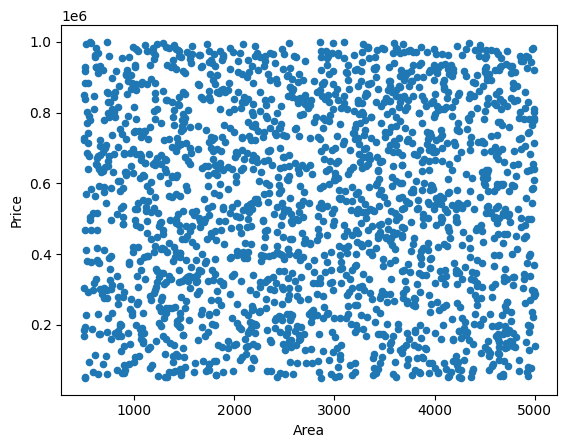

In [84]:
df.plot(kind="scatter", x="Area", y="Price")
